# TQQQ / QQQ Leverage Ratio Inefficiency Analysis

TQQQ targets **3× the daily RTH return** of QQQ. On any given day the realized leverage ratio
(`TQQQ_rth_return / QQQ_rth_return`) should cluster around 3.0 before fees and tracking error.

**Questions:**
1. How much does the realized leverage ratio vary day-to-day?
2. Is there mean-reversion? When TQQQ delivers only 2.9× one day, does it compensate the next?
3. Does the **premarket** leverage ratio (TQQQ_pre / QQQ_pre) predict where the RTH ratio lands?
4. When TQQQ appears "cheap" premarket (pre-ratio < 2.9), does RTH over-deliver?

> **Data:** Run `python fetch_bars.py` first to populate the `data/` CSVs.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('tab10')
DATA_DIR = Path('data')

# Minimum |QQQ RTH return| to include in ratio calculations.
# On near-flat days the ratio is division noise, not a real leverage signal.
MIN_QQQ_RTH = 0.001   # 0.1%
MIN_QQQ_PRE = 0.0005  # 0.05%

## 1. Load Data & Build Pairs DataFrame

In [2]:
def load(sym):
    p = DATA_DIR / f'{sym.lower()}_daily.csv'
    if not p.exists():
        raise FileNotFoundError(f'{p} — run fetch_bars.py first')
    df = pd.read_csv(p, parse_dates=['date'])
    df['date'] = pd.to_datetime(df['date']).dt.date
    return df.sort_values('date').reset_index(drop=True)

qqq  = load('QQQ')
tqqq = load('TQQQ')

# Merge on date
df = pd.merge(
    qqq[['date', 'premarket_return', 'rth_return',
         'last30_pre_return', 'first30_rth_return', 'rest_rth_return']]
       .rename(columns=lambda c: f'qqq_{c}' if c != 'date' else c),
    tqqq[['date', 'premarket_return', 'rth_return',
          'last30_pre_return', 'first30_rth_return', 'rest_rth_return']]
        .rename(columns=lambda c: f'tqqq_{c}' if c != 'date' else c),
    on='date', how='inner'
).sort_values('date').reset_index(drop=True)

print(f'Paired days: {len(df)}  ({df["date"].min()} → {df["date"].max()})')
print(df[['qqq_rth_return','tqqq_rth_return','qqq_premarket_return','tqqq_premarket_return']]
      .describe().applymap(lambda x: f'{x*100:.3f}%'))

Paired days: 1121  (2022-01-04 → 2026-06-24)
      qqq_rth_return tqqq_rth_return qqq_premarket_return  \
count    112100.000%     112100.000%          112100.000%   
mean          0.030%          0.084%               0.033%   
std           1.227%          3.663%               0.901%   
min          -5.044%        -14.298%              -6.441%   
25%          -0.615%         -1.817%              -0.400%   
50%           0.096%          0.289%               0.057%   
75%           0.707%          2.097%               0.472%   
max          12.129%         35.530%               4.895%   

      tqqq_premarket_return  
count           112100.000%  
mean                -0.027%  
std                  3.376%  
min                -49.411%  
25%                 -1.237%  
50%                  0.136%  
75%                  1.378%  
max                 14.602%  


## 2. Realized Leverage Ratio — Distribution

In [3]:
# RTH leverage ratio — only on days QQQ moved enough to make the ratio meaningful
rth_mask = df['qqq_rth_return'].abs() >= MIN_QQQ_RTH
df['leverage_rth'] = np.where(
    rth_mask,
    df['tqqq_rth_return'] / df['qqq_rth_return'],
    np.nan
)

# PRE leverage ratio
pre_mask = df['qqq_premarket_return'].abs() >= MIN_QQQ_PRE
df['leverage_pre'] = np.where(
    pre_mask,
    df['tqqq_premarket_return'] / df['qqq_premarket_return'],
    np.nan
)

# Last-30-min PRE leverage ratio
last30_mask = df['qqq_last30_pre_return'].abs() >= MIN_QQQ_PRE
df['leverage_last30_pre'] = np.where(
    last30_mask,
    df['tqqq_last30_pre_return'] / df['qqq_last30_pre_return'],
    np.nan
)

lev = df['leverage_rth'].dropna()
print(f'RTH leverage ratio — n={len(lev)} days (|QQQ RTH| ≥ {MIN_QQQ_RTH*100:.1f}%)')
print(f'  mean   = {lev.mean():.4f}x')
print(f'  median = {lev.median():.4f}x')
print(f'  std    = {lev.std():.4f}')
print(f'  min    = {lev.min():.4f}x')
print(f'  max    = {lev.max():.4f}x')
print(f'  days leverage < 2.9x : {(lev < 2.9).sum()}  ({(lev < 2.9).mean()*100:.1f}%)')
print(f'  days leverage < 3.0x : {(lev < 3.0).sum()}  ({(lev < 3.0).mean()*100:.1f}%)')
print(f'  days leverage > 3.1x : {(lev > 3.1).sum()}  ({(lev > 3.1).mean()*100:.1f}%)')
print(f'  days leverage > 3.0x : {(lev > 3.0).sum()}  ({(lev > 3.0).mean()*100:.1f}%)')

RTH leverage ratio — n=1035 days (|QQQ RTH| ≥ 0.1%)
  mean   = 2.9770x
  median = 2.9760x
  std    = 0.2717
  min    = 0.2249x
  max    = 5.7830x
  days leverage < 2.9x : 274  (26.5%)
  days leverage < 3.0x : 614  (59.3%)
  days leverage > 3.1x : 189  (18.3%)
  days leverage > 3.0x : 421  (40.7%)


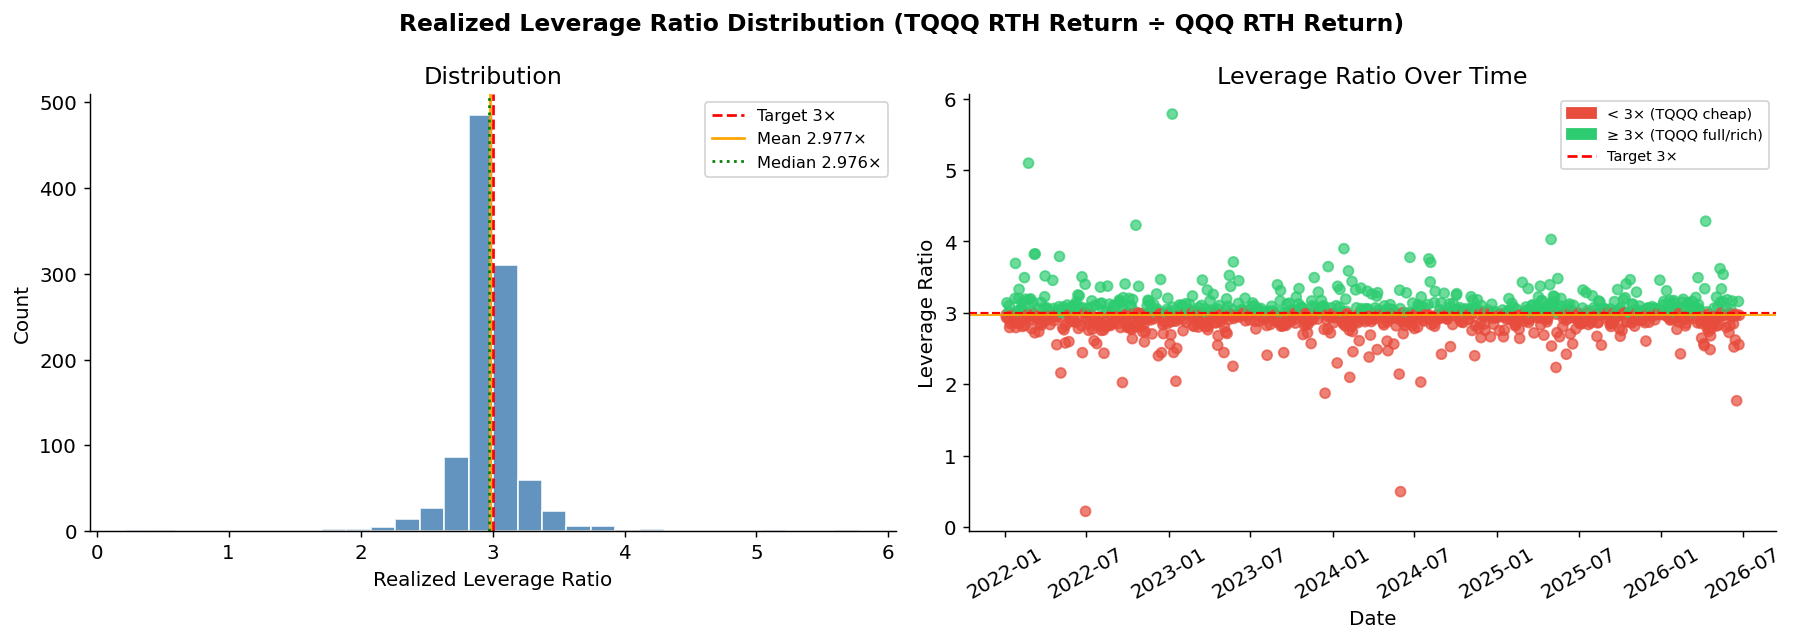

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Realized Leverage Ratio Distribution (TQQQ RTH Return ÷ QQQ RTH Return)',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.hist(lev, bins=30, edgecolor='white', color='steelblue', alpha=0.85)
ax.axvline(3.0, color='red', linestyle='--', linewidth=1.5, label='Target 3×')
ax.axvline(lev.mean(), color='orange', linestyle='-', linewidth=1.5,
           label=f'Mean {lev.mean():.3f}×')
ax.axvline(lev.median(), color='green', linestyle=':', linewidth=1.5,
           label=f'Median {lev.median():.3f}×')
ax.set_xlabel('Realized Leverage Ratio')
ax.set_ylabel('Count')
ax.set_title('Distribution')
ax.legend(fontsize=9)

ax = axes[1]
dates = pd.to_datetime(df.loc[df['leverage_rth'].notna(), 'date'])
ax.scatter(dates, lev.values, s=30, alpha=0.7,
           c=['#e74c3c' if x < 3.0 else '#2ecc71' for x in lev.values])
ax.axhline(3.0, color='red', linestyle='--', linewidth=1.2, label='Target 3×')
ax.axhline(lev.mean(), color='orange', linestyle='-', linewidth=1, label=f'Mean {lev.mean():.3f}×')
ax.set_xlabel('Date')
ax.set_ylabel('Leverage Ratio')
ax.set_title('Leverage Ratio Over Time')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=30)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#e74c3c', label='< 3× (TQQQ cheap)'),
    Patch(color='#2ecc71', label='≥ 3× (TQQQ full/rich)'),
    plt.Line2D([0],[0], color='red', linestyle='--', label='Target 3×'),
], fontsize=8)

plt.tight_layout()
plt.show()

## 3. Mean Reversion — Does a Low-Leverage Day Predict the Next Day?

In [5]:
lev_series = df['leverage_rth'].dropna().reset_index(drop=True)
lev_today = lev_series[:-1].values
lev_next  = lev_series[1:].values

r, p = stats.pearsonr(lev_today, lev_next)
sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))

print('=== Autocorrelation of Daily Leverage Ratio (lag-1) ===')
print(f'  Pearson r = {r:+.4f}   p = {p:.4f}  {sig}')
print()
print('r > 0 → momentum (low leverage begets low leverage)')
print('r < 0 → mean reversion (low leverage today → high leverage tomorrow)')
print()

# Conditional: split by whether today's ratio was below or above 3
mask_cheap = lev_today < 3.0
mask_rich  = lev_today >= 3.0

print(f'When today leverage < 3.0  (n={mask_cheap.sum()}):  next-day mean = {lev_next[mask_cheap].mean():.4f}×')
print(f'When today leverage ≥ 3.0  (n={mask_rich.sum()}):  next-day mean = {lev_next[mask_rich].mean():.4f}×')

tstat, tpval = stats.ttest_ind(lev_next[mask_cheap], lev_next[mask_rich])
print(f'\nt-test (cheap vs rich): t={tstat:.3f}  p={tpval:.4f}')

=== Autocorrelation of Daily Leverage Ratio (lag-1) ===
  Pearson r = -0.0295   p = 0.3441  n.s.

r > 0 → momentum (low leverage begets low leverage)
r < 0 → mean reversion (low leverage today → high leverage tomorrow)

When today leverage < 3.0  (n=613):  next-day mean = 2.9851×
When today leverage ≥ 3.0  (n=421):  next-day mean = 2.9651×

t-test (cheap vs rich): t=1.163  p=0.2452


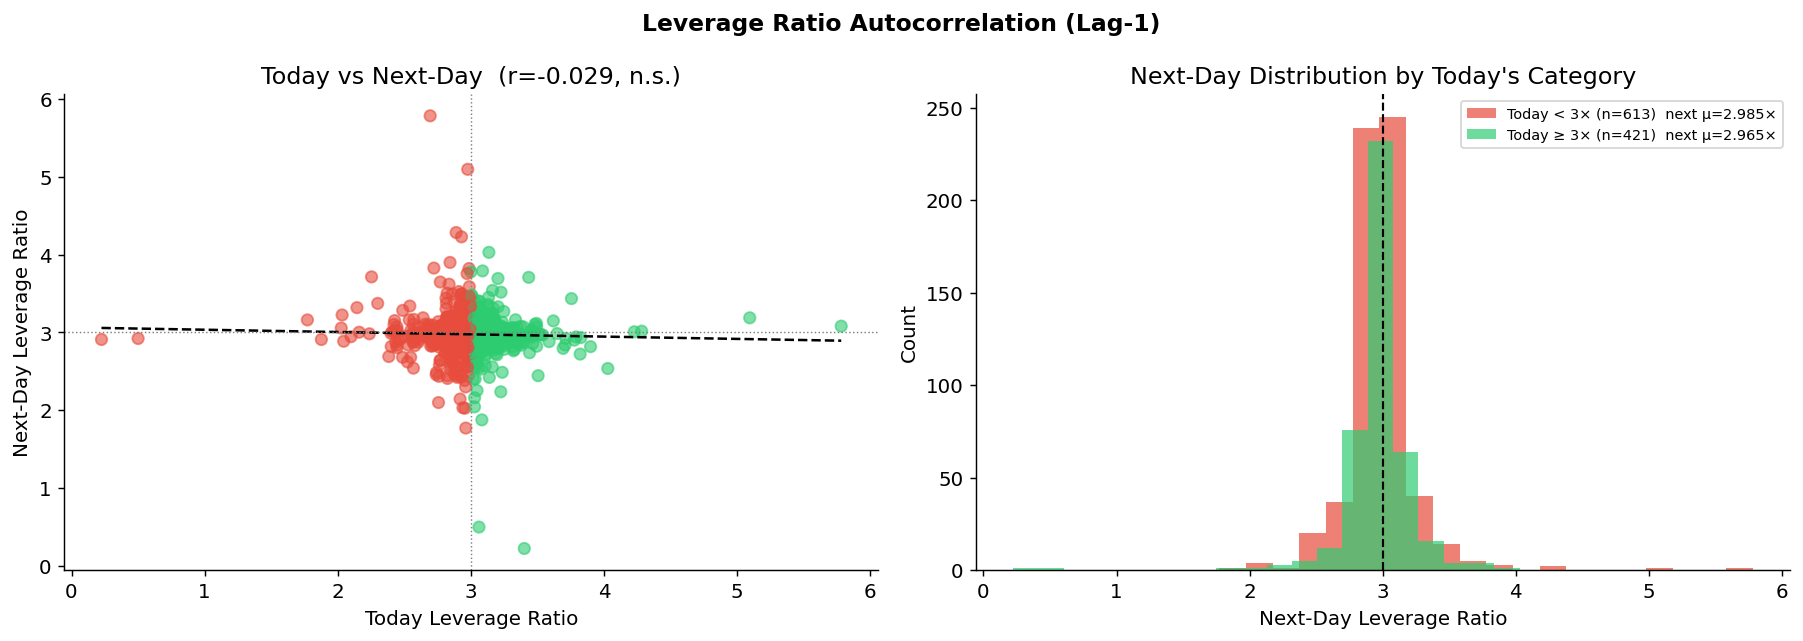

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Leverage Ratio Autocorrelation (Lag-1)', fontsize=13, fontweight='bold')

ax = axes[0]
colors = ['#e74c3c' if x < 3 else '#2ecc71' for x in lev_today]
ax.scatter(lev_today, lev_next, c=colors, alpha=0.6, s=40)
m, b, *_ = stats.linregress(lev_today, lev_next)
xl = np.linspace(lev_today.min(), lev_today.max(), 100)
ax.plot(xl, m*xl + b, 'k--', linewidth=1.4)
ax.axvline(3.0, color='grey', linestyle=':', linewidth=0.8)
ax.axhline(3.0, color='grey', linestyle=':', linewidth=0.8)
ax.set_xlabel('Today Leverage Ratio')
ax.set_ylabel('Next-Day Leverage Ratio')
ax.set_title(f'Today vs Next-Day  (r={r:+.3f}, {sig})')

ax = axes[1]
# Distribution of next-day leverage, split by today cheap/rich
ax.hist(lev_next[mask_cheap], bins=20, alpha=0.7, color='#e74c3c',
        label=f'Today < 3× (n={mask_cheap.sum()})  next μ={lev_next[mask_cheap].mean():.3f}×')
ax.hist(lev_next[mask_rich], bins=20, alpha=0.7, color='#2ecc71',
        label=f'Today ≥ 3× (n={mask_rich.sum()})  next μ={lev_next[mask_rich].mean():.3f}×')
ax.axvline(3.0, color='black', linestyle='--', linewidth=1.2)
ax.set_xlabel('Next-Day Leverage Ratio')
ax.set_ylabel('Count')
ax.set_title('Next-Day Distribution by Today\'s Category')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4. Does the Premarket Leverage Ratio Predict RTH Leverage Ratio?

In [7]:
pairs_lev = [
    ('leverage_pre',      'leverage_rth',  'Full PRE leverage → RTH leverage'),
    ('leverage_last30_pre','leverage_rth', 'Last30 PRE leverage → RTH leverage'),
]

print('=== Premarket Leverage Ratio → RTH Leverage Ratio ===\n')
for pred, target, label in pairs_lev:
    valid = df[[pred, target]].dropna()
    if len(valid) < 5:
        print(f'{label}: insufficient data (n={len(valid)})')
        continue
    r, p = stats.pearsonr(valid[pred], valid[target])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    print(f'{label}')
    print(f'  n={len(valid)}  r={r:+.4f}  p={p:.4f}  {sig}')

    X = sm.add_constant(valid[pred])
    ols = sm.OLS(valid[target], X).fit()
    print(f'  OLS R²={ols.rsquared:.4f}  slope={ols.params[pred]:.4f}  intercept={ols.params["const"]:.4f}')
    print()

=== Premarket Leverage Ratio → RTH Leverage Ratio ===

Full PRE leverage → RTH leverage
  n=966  r=+0.0253  p=0.4330  n.s.
  OLS R²=0.0006  slope=0.0017  intercept=2.9759

Last30 PRE leverage → RTH leverage
  n=965  r=+0.0253  p=0.4325  n.s.
  OLS R²=0.0006  slope=0.0017  intercept=2.9761



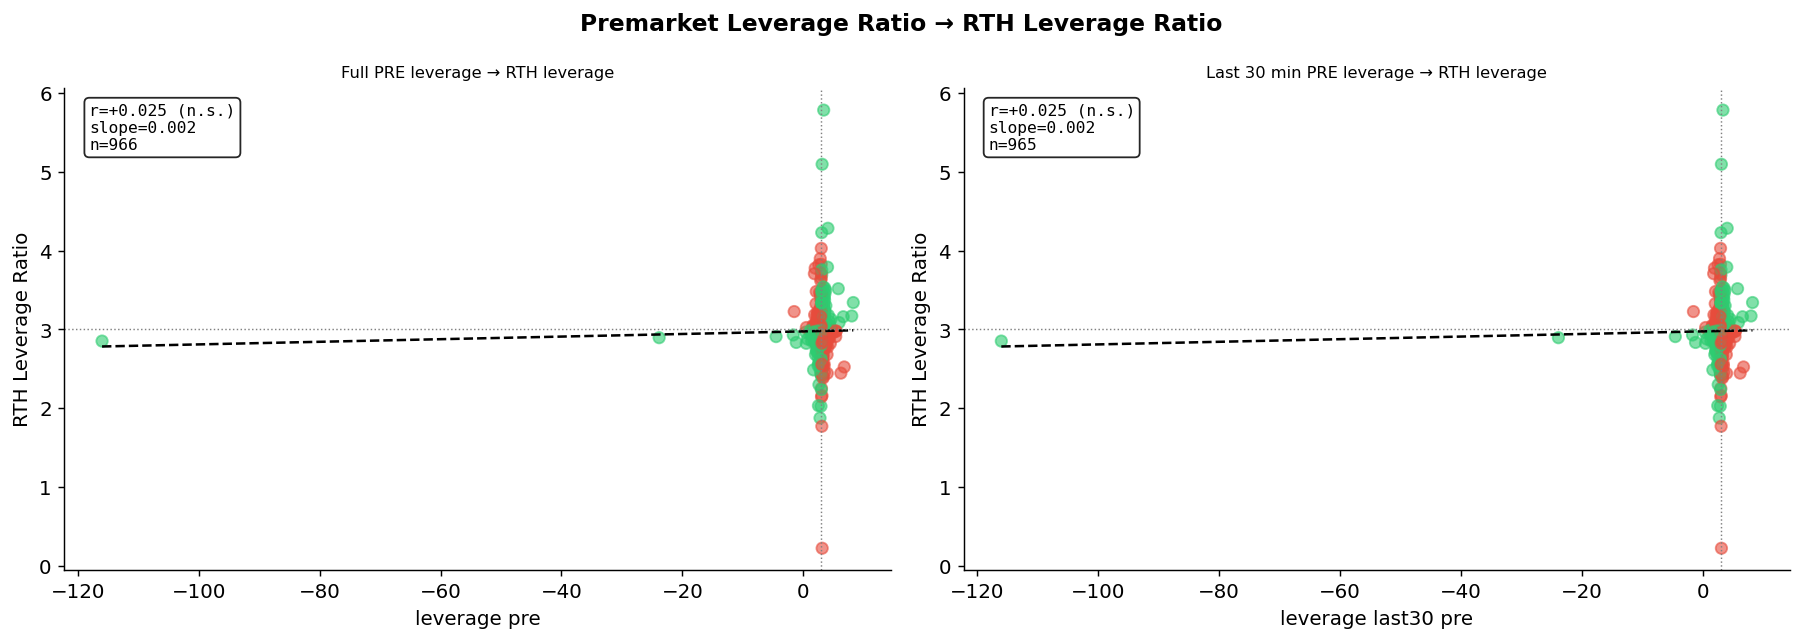

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Premarket Leverage Ratio → RTH Leverage Ratio', fontsize=13, fontweight='bold')

plot_pairs = [
    ('leverage_pre',       'Full PRE leverage → RTH leverage'),
    ('leverage_last30_pre','Last 30 min PRE leverage → RTH leverage'),
]
for ax, (pred, title) in zip(axes, plot_pairs):
    valid = df[[pred, 'leverage_rth']].dropna()
    x = valid[pred]
    y = valid['leverage_rth']

    colors = ['#2ecc71' if (xi < 3) == (yi < 3) else '#e74c3c' for xi, yi in zip(x, y)]
    ax.scatter(x, y, c=colors, alpha=0.6, s=40)

    m, b, r_val, p_val, _ = stats.linregress(x, y)
    xl = np.linspace(x.min(), x.max(), 100)
    ax.plot(xl, m*xl + b, 'k--', linewidth=1.4)
    ax.axvline(3.0, color='grey', linestyle=':', linewidth=0.8)
    ax.axhline(3.0, color='grey', linestyle=':', linewidth=0.8)

    sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'n.s.'))
    ax.text(0.03, 0.97,
            f'r={r_val:+.3f} ({sig})\nslope={m:.3f}\nn={len(valid)}',
            transform=ax.transAxes, ha='left', va='top', fontsize=9, fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
    ax.set_xlabel(pred.replace('_', ' '))
    ax.set_ylabel('RTH Leverage Ratio')
    ax.set_title(title, fontsize=9)

plt.tight_layout()
plt.show()

## 5. The "TQQQ Cheap" Setup — Conditional RTH Analysis

In [9]:
# Classify each day by whether TQQQ looked cheap premarket
valid_pre = df[df['leverage_pre'].notna()].copy()

thresholds = [2.7, 2.8, 2.9, 3.0, 3.1]

print('=== When TQQQ pre-leverage < threshold: what does RTH leverage look like? ===\n')
print(f'{"Threshold":<14} {"n cheap":>8} {"RTH lev mean":>14} {"RTH lev median":>15} {"% RTH≥3":>10}')
print('-' * 65)

for t in thresholds:
    cheap = valid_pre[valid_pre['leverage_pre'] < t]
    if len(cheap) == 0:
        continue
    rth_cheap = cheap['leverage_rth'].dropna()
    print(f'pre_lev < {t:.1f}   {len(cheap):>8}  {rth_cheap.mean():>14.4f}×  {rth_cheap.median():>15.4f}×  '
          f'{(rth_cheap >= 3.0).mean()*100:>9.1f}%')

print()
# Also show when TQQQ is rich
rich = valid_pre[valid_pre['leverage_pre'] >= 3.0]
rth_rich = rich['leverage_rth'].dropna()
print(f'pre_lev ≥ 3.0  {len(rich):>8}  {rth_rich.mean():>14.4f}×  {rth_rich.median():>15.4f}×  '
      f'{(rth_rich >= 3.0).mean()*100:>9.1f}%')

=== When TQQQ pre-leverage < threshold: what does RTH leverage look like? ===

Threshold       n cheap   RTH lev mean  RTH lev median    % RTH≥3
-----------------------------------------------------------------
pre_lev < 2.7        147          2.9729×           2.9696×       37.5%
pre_lev < 2.8        209          2.9550×           2.9603×       33.5%
pre_lev < 2.9        330          2.9686×           2.9629×       34.8%
pre_lev < 3.0        583          2.9617×           2.9611×       33.5%
pre_lev < 3.1        772          2.9689×           2.9683×       38.0%

pre_lev ≥ 3.0       460          3.0046×           3.0027×       50.6%


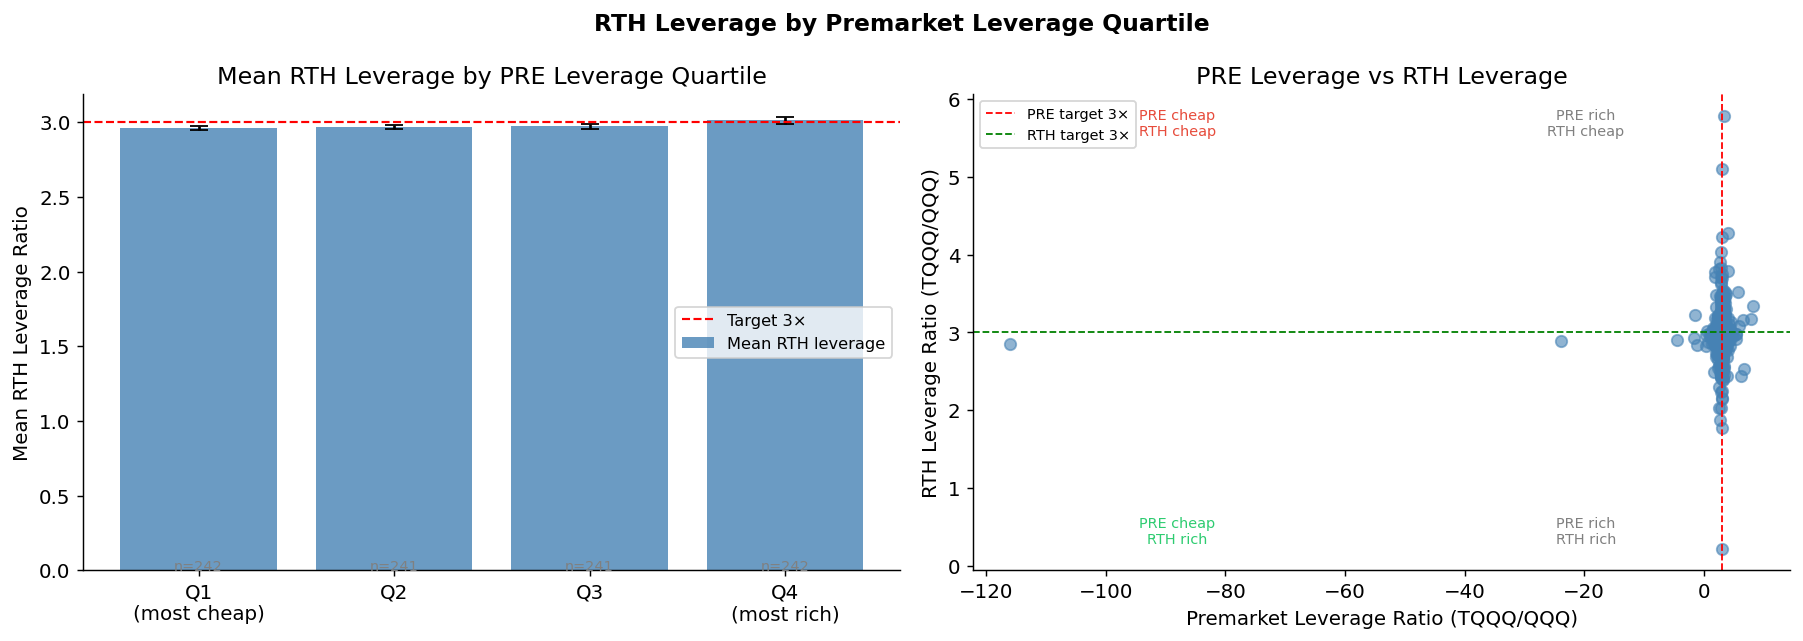


Summary table:
     pre_lev_bin     mean   median      std  count
Q1\n(most cheap) 2.963253 2.962913 0.203921    242
              Q2 2.972255 2.963647 0.204945    241
              Q3 2.972898 2.991453 0.234133    241
 Q4\n(most rich) 3.013831 2.997424 0.363099    242


In [10]:
# Bin pre-leverage into quantiles and show mean RTH leverage per bin
valid_both = df[df['leverage_pre'].notna() & df['leverage_rth'].notna()].copy()

valid_both['pre_lev_bin'] = pd.qcut(
    valid_both['leverage_pre'], q=4,
    labels=['Q1\n(most cheap)', 'Q2', 'Q3', 'Q4\n(most rich)']
)

summary = valid_both.groupby('pre_lev_bin', observed=True)['leverage_rth'].agg(
    ['mean', 'median', 'std', 'count']
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RTH Leverage by Premarket Leverage Quartile', fontsize=13, fontweight='bold')

ax = axes[0]
x = np.arange(len(summary))
ax.bar(x, summary['mean'], color='steelblue', alpha=0.8, label='Mean RTH leverage')
ax.errorbar(x, summary['mean'],
            yerr=summary['std'] / np.sqrt(summary['count']),
            fmt='none', color='black', capsize=5)
ax.axhline(3.0, color='red', linestyle='--', linewidth=1.2, label='Target 3×')
ax.set_xticks(x)
ax.set_xticklabels(summary['pre_lev_bin'])
ax.set_ylabel('Mean RTH Leverage Ratio')
ax.set_title('Mean RTH Leverage by PRE Leverage Quartile')
ax.legend(fontsize=9)
for i, row in summary.iterrows():
    ax.text(i, ax.get_ylim()[0] * 0.05 + ax.get_ylim()[0],
            f'n={int(row["count"])}', ha='center', fontsize=8, color='grey')

# Right panel: scatter of pre_leverage vs RTH leverage with 3x reference lines
ax = axes[1]
ax.scatter(valid_both['leverage_pre'], valid_both['leverage_rth'],
           alpha=0.6, s=40, color='steelblue')
ax.axvline(3.0, color='red', linestyle='--', linewidth=1, label='PRE target 3×')
ax.axhline(3.0, color='green', linestyle='--', linewidth=1, label='RTH target 3×')

# Quadrant labels
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.text(0.25, 0.97, 'PRE cheap\nRTH cheap', transform=ax.transAxes,
        ha='center', va='top', fontsize=8, color='#e74c3c')
ax.text(0.75, 0.97, 'PRE rich\nRTH cheap', transform=ax.transAxes,
        ha='center', va='top', fontsize=8, color='grey')
ax.text(0.25, 0.05, 'PRE cheap\nRTH rich', transform=ax.transAxes,
        ha='center', va='bottom', fontsize=8, color='#2ecc71')
ax.text(0.75, 0.05, 'PRE rich\nRTH rich', transform=ax.transAxes,
        ha='center', va='bottom', fontsize=8, color='grey')

ax.set_xlabel('Premarket Leverage Ratio (TQQQ/QQQ)')
ax.set_ylabel('RTH Leverage Ratio (TQQQ/QQQ)')
ax.set_title('PRE Leverage vs RTH Leverage')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\nSummary table:')
print(summary.to_string(index=False))

## 6. Return Attribution — TQQQ vs QQQ Directly

In [11]:
# On days TQQQ appears cheap premarket, does it actually outperform on an RTH basis?
# "Outperform" = TQQQ_rth > 3 × QQQ_rth (i.e., the leverage more than compensates)

valid_both['tqqq_excess_rth'] = df['tqqq_rth_return'] - 3 * df['qqq_rth_return']
valid_both['cheap_pre'] = valid_both['leverage_pre'] < 3.0

cheap_excess = valid_both.loc[valid_both['cheap_pre'], 'tqqq_excess_rth'].dropna()
rich_excess  = valid_both.loc[~valid_both['cheap_pre'], 'tqqq_excess_rth'].dropna()

print('=== RTH Excess Return of TQQQ over 3×QQQ ===')
print('(Positive = TQQQ over-delivered vs 3× target; negative = under-delivered)\n')
print(f'All days         (n={valid_both["tqqq_excess_rth"].notna().sum()}):'
      f'  mean excess = {valid_both["tqqq_excess_rth"].mean()*100:+.4f}%')
print(f'PRE leverage<3   (n={len(cheap_excess)}):'
      f'  mean excess = {cheap_excess.mean()*100:+.4f}%')
print(f'PRE leverage≥3   (n={len(rich_excess)}):'
      f'  mean excess = {rich_excess.mean()*100:+.4f}%')

if len(cheap_excess) > 1 and len(rich_excess) > 1:
    t, p = stats.ttest_ind(cheap_excess, rich_excess)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    print(f'\nt-test (cheap vs rich): t={t:.3f}  p={p:.4f}  {sig}')

=== RTH Excess Return of TQQQ over 3×QQQ ===
(Positive = TQQQ over-delivered vs 3× target; negative = under-delivered)

All days         (n=966):  mean excess = -0.0070%
PRE leverage<3   (n=541):  mean excess = -0.0075%
PRE leverage≥3   (n=425):  mean excess = -0.0064%

t-test (cheap vs rich): t=-0.110  p=0.9125  n.s.


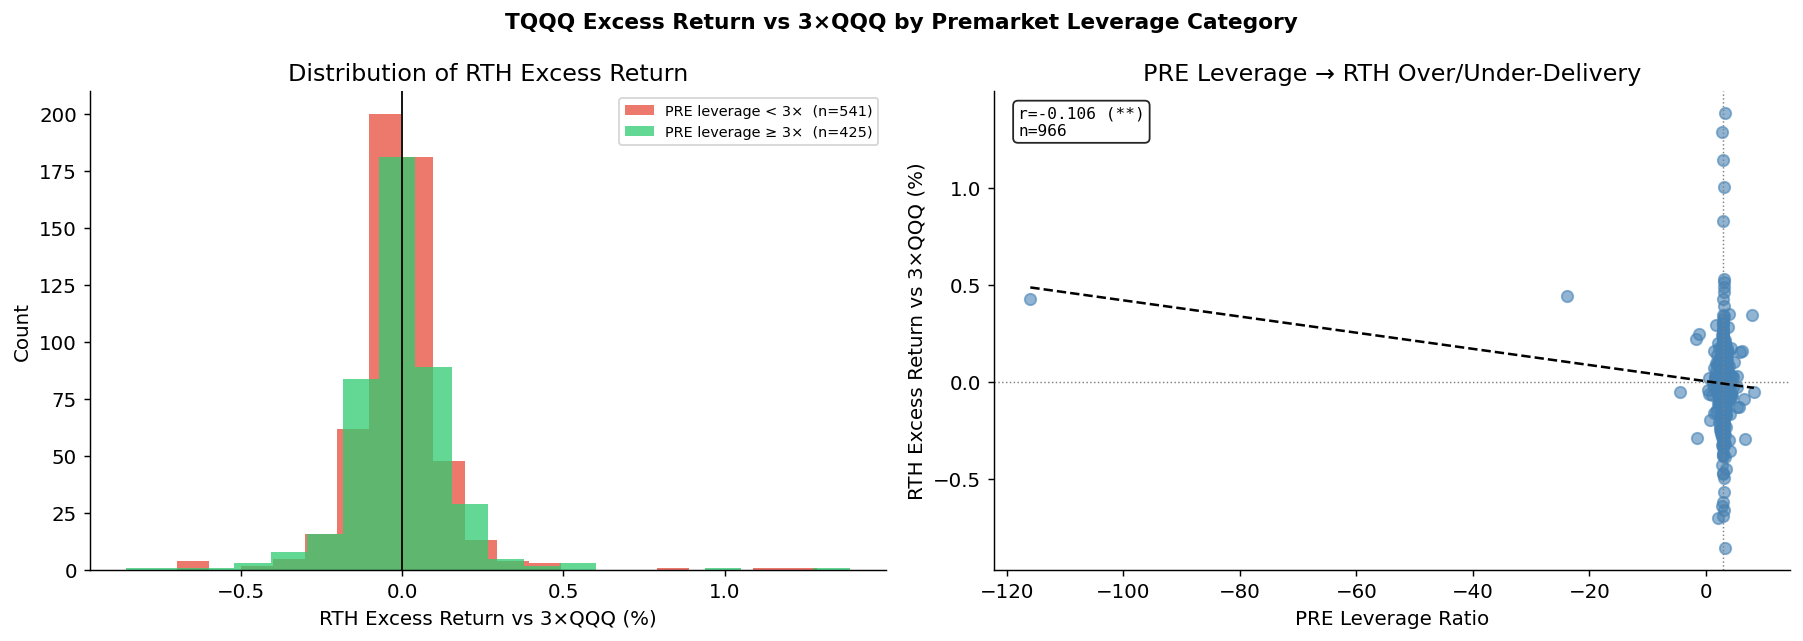

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('TQQQ Excess Return vs 3×QQQ by Premarket Leverage Category',
             fontsize=12, fontweight='bold')

ax = axes[0]
ax.hist(cheap_excess * 100, bins=20, alpha=0.75, color='#e74c3c',
        label=f'PRE leverage < 3×  (n={len(cheap_excess)})')
ax.hist(rich_excess * 100, bins=20, alpha=0.75, color='#2ecc71',
        label=f'PRE leverage ≥ 3×  (n={len(rich_excess)})')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('RTH Excess Return vs 3×QQQ (%)')
ax.set_ylabel('Count')
ax.set_title('Distribution of RTH Excess Return')
ax.legend(fontsize=8)

ax = axes[1]
# Scatter: PRE leverage vs RTH excess
valid_scatter = valid_both[['leverage_pre', 'tqqq_excess_rth']].dropna()
ax.scatter(valid_scatter['leverage_pre'],
           valid_scatter['tqqq_excess_rth'] * 100,
           alpha=0.6, s=40, color='steelblue')
ax.axvline(3.0, color='grey', linestyle=':', linewidth=0.8)
ax.axhline(0, color='grey', linestyle=':', linewidth=0.8)
m, b, r_val, p_val, _ = stats.linregress(
    valid_scatter['leverage_pre'],
    valid_scatter['tqqq_excess_rth'] * 100
)
xl = np.linspace(valid_scatter['leverage_pre'].min(), valid_scatter['leverage_pre'].max(), 100)
ax.plot(xl, m*xl + b, 'k--', linewidth=1.4)
sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'n.s.'))
ax.text(0.03, 0.97,
        f'r={r_val:+.3f} ({sig})\nn={len(valid_scatter)}',
        transform=ax.transAxes, ha='left', va='top', fontsize=9, fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
ax.set_xlabel('PRE Leverage Ratio')
ax.set_ylabel('RTH Excess Return vs 3×QQQ (%)')
ax.set_title('PRE Leverage → RTH Over/Under-Delivery')

plt.tight_layout()
plt.show()

## 7. Interpretation

| Metric | What to look for |
|--------|------------------|
| **Leverage ratio mean** | Should be ~3.0 on average. Persistent deviation indicates structural tracking error (fees, rebalancing costs, volatility drag). |
| **Leverage ratio std** | Day-to-day scatter around 3×. High std means big daily deviations — potentially exploitable, but also risky. |
| **Lag-1 autocorrelation (§3)** | Negative → mean reversion: a cheap day today predicts a rich day tomorrow. Positive → momentum. Near-zero → the ratio is a random walk. |
| **PRE leverage → RTH leverage (§4)** | If r is large and significant, the premarket ratio reliably predicts RTH ratio — you can act on it at the open. |
| **RTH excess return when PRE cheap (§6)** | The direct test of the trade idea: when TQQQ looks cheap premarket, does it actually over-deliver vs 3×QQQ during RTH? |

### Important caveats
- **TQQQ rebalances daily.** The 3× target is a *daily* return target, not intra-day. Comparing premarket TQQQ/QQQ ratios is valid but noisier than RTH.
- **Volatility drag** means TQQQ will tend to under-deliver 3× over multi-day horizons, but each *individual day* should still centre near 3×.
- **Liquidity and spreads.** TQQQ's premarket spread is wider than QQQ's; the apparent leverage discount may partly reflect bid-ask, not a real NAV gap.
- **Sample size.** 92 days is small. Any pattern discovered here needs out-of-sample validation.